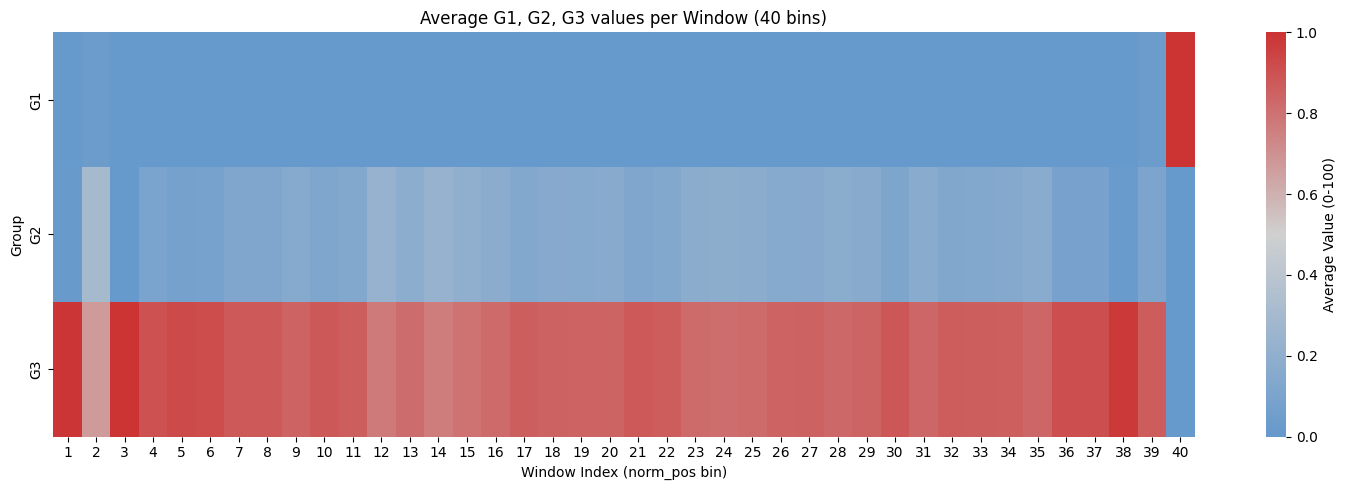

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


filename = 'DYZ1.filtered.blocks.add_INV.txt'


df_dyz1 = pd.read_csv(filename, sep='\t', header=0)


df_dyz1['window'] = pd.cut(df_dyz1['norm_pos'], bins=40, labels=range(1, 41))


df_mean = df_dyz1.groupby('window')[['G1', 'G2', 'G3']].mean()


plot_data = df_mean.T


colors = ["#6699cc", "#d0d0d0", "#cc3333"]
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)


plt.figure(figsize=(15, 5))


sns.heatmap(data=plot_data, 
            cmap=cmap, 
            vmin=0, vmax=1,

            cbar_kws={'label': 'Average Value (0-100)'})


plt.title('Average G1, G2, G3 values per Window (40 bins)')
plt.xlabel('Window Index (norm_pos bin)')
plt.ylabel('Group')

plt.tight_layout()
plt.savefig('DYZ1_heatmap.pdf', dpi=300)
plt.show()

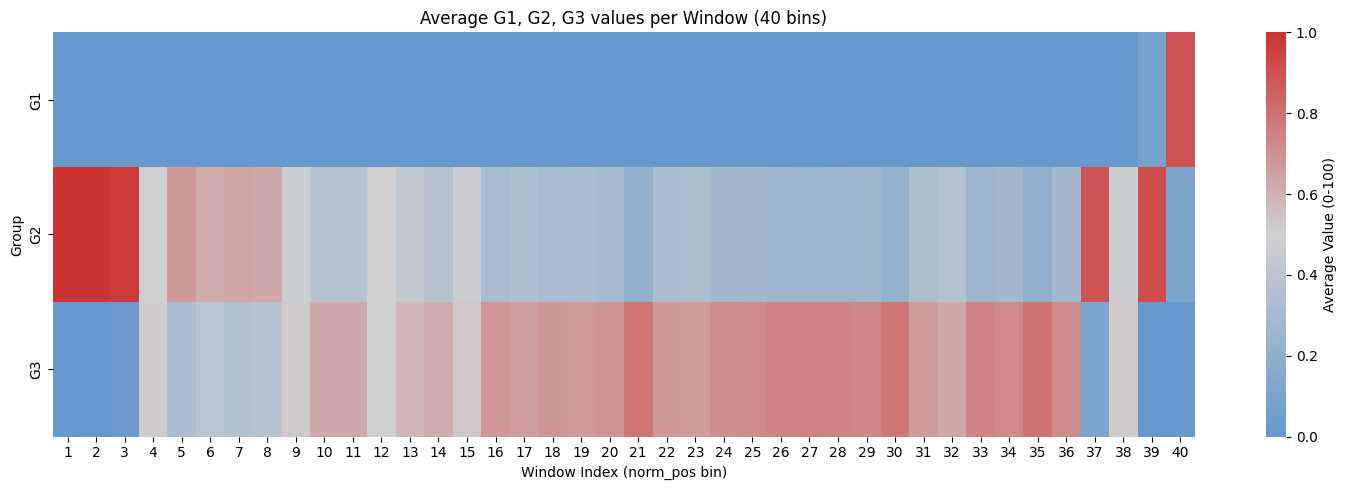

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

filename = 'DYZ2.filtered.blocks.add_INV.txt'


df_dyz1 = pd.read_csv(filename, sep='\t', header=0)

df_dyz1['window'] = pd.cut(df_dyz1['norm_pos'], bins=40, labels=range(1, 41))


df_mean = df_dyz1.groupby('window')[['G1', 'G2', 'G3']].mean()


plot_data = df_mean.T


colors = ["#6699cc", "#d0d0d0", "#cc3333"]
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)


plt.figure(figsize=(15, 5))


sns.heatmap(data=plot_data, 
            cmap=cmap, 
            vmin=0, vmax=1,
         
            cbar_kws={'label': 'Average Value (0-100)'})

plt.title('Average G1, G2, G3 values per Window (40 bins)')
plt.xlabel('Window Index (norm_pos bin)')
plt.ylabel('Group')

plt.tight_layout()
plt.savefig('DYZ2_heatmap.pdf', dpi=300)
plt.show()

DYZ1 Filtered: 2/2887 blocks
DYZ2 Filtered: 162/2957 blocks


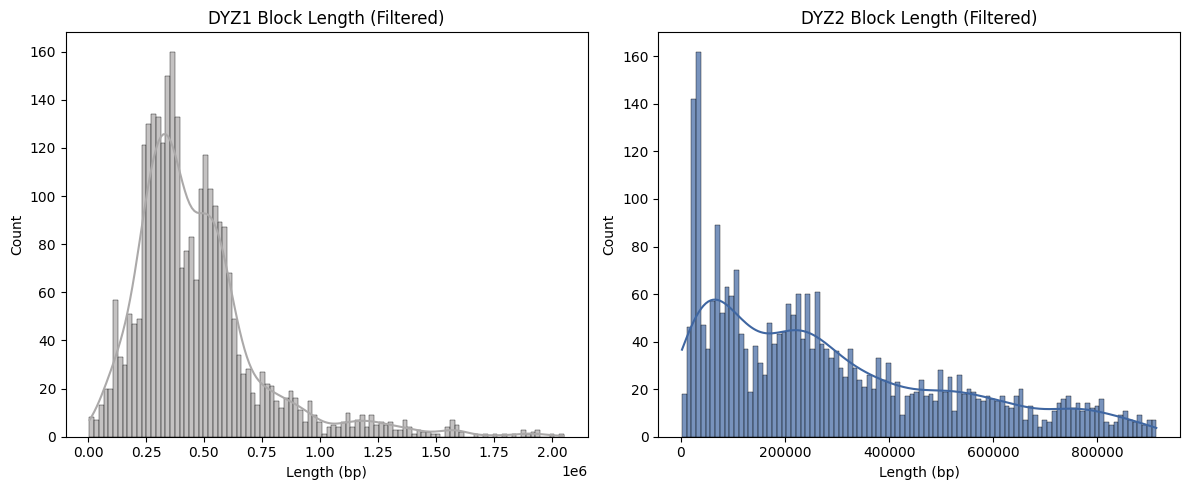

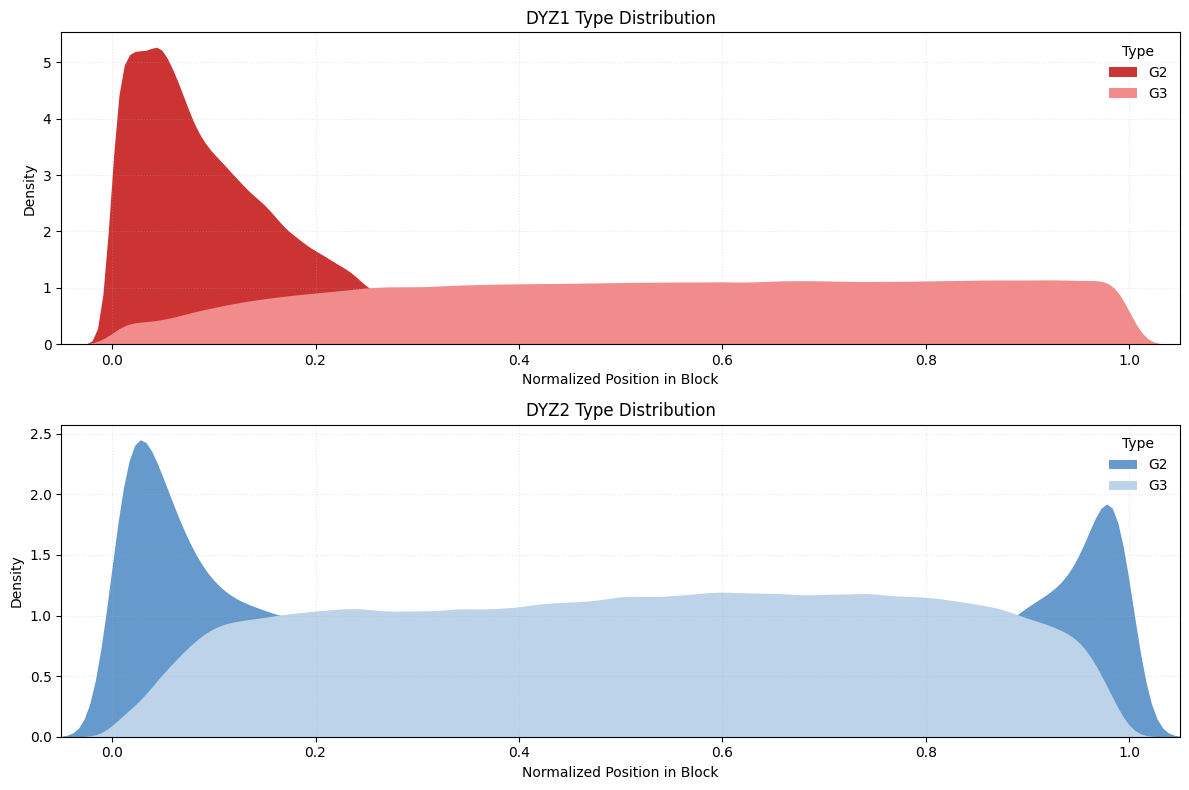

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from scipy import stats


DATA_SOURCES = {
    "DYZ1": {"path": "./DYZ1", "color": "#ABA9A9"},
    "DYZ2": {"path": "./DYZ2", "color": "#3F66A1"}
}
BLOCK_COL = 6
START_COL = 1
END_COL = 2
CONFIDENCE_LEVEL = 0.95

def calculate_block_lengths(data_source):
    all_lengths = []
    
    for f in os.listdir(data_source["path"]):
        if f.endswith(".bed"):
            sample_name = f.split('.')[0]
            file_path = os.path.join(data_source["path"], f)
            df = pd.read_csv(file_path, sep="\t", header=None)
            
            df['global_block_id'] = df[BLOCK_COL].astype(str) + '_' + sample_name
            
            for global_id, group in df.groupby('global_block_id'):
                block_length = group[END_COL].max() - group[START_COL].min()
                all_lengths.append({
                    "source": data_source["path"].split("/")[-1],
                    "global_block_id": global_id,
                    "length": block_length,
                    "sample": sample_name
                })
    
    return pd.DataFrame(all_lengths)

def filter_blocks(source_df):


    mu = source_df['length'].mean()
    sigma = source_df['length'].std()
    z_score = stats.norm.ppf((1 + CONFIDENCE_LEVEL) / 2)
    lower = mu - z_score * sigma
    upper = mu + z_score * sigma
    

    filtered = source_df[(source_df['length'] >= lower) & (source_df['length'] <= upper)].copy()
    print(f"{source_df['source'].iloc[0]} Filtered: {len(source_df)-len(filtered)}/{len(source_df)} blocks")
    return filtered

def analyze_block_lengths():

    all_blocks = pd.concat([calculate_block_lengths(v) for k,v in DATA_SOURCES.items()])
    

    filtered_data = {}
    for source_name in DATA_SOURCES:
        source_blocks = all_blocks[all_blocks['source'] == source_name]
        filtered = filter_blocks(source_blocks)
        filtered_data[source_name] = filtered
    

    plt.figure(figsize=(12, 5))
    for idx, (source_name, df) in enumerate(filtered_data.items(), 1):
        plt.subplot(1, 2, idx)
        sns.histplot(df['length'], 
                    color=DATA_SOURCES[source_name]["color"], 
                    kde=True,
                    bins=100,
                    alpha=0.7)
        plt.title(f"{source_name} Block Length (Filtered)")
        plt.xlabel("Length (bp)")
    plt.tight_layout() 
    plt.show()
    
    return filtered_data

filtered_blocks = analyze_block_lengths()


TYPE_COLORS = {
    "DYZ1": { 'G2': '#cc3333', 'G3': '#f28c8c'},
    "DYZ2": {'G2': '#6699cc','G3':'#bdd3e9'}
}
BANDWIDTH = 0.05
TYPE_COL = 7 


def process_normalized_positions(filtered_blocks):
    """计算归一化位置（基于全局唯一block_id）"""
    all_positions = []
    
    for source_name, blocks_df in filtered_blocks.items():
        path = DATA_SOURCES[source_name]["path"]
        valid_blocks = blocks_df['global_block_id'].unique()
        
        for f in os.listdir(path):
            if f.endswith(".bed"):
                sample_name = f.split('.')[0]
                file_path = os.path.join(path, f)
                df = pd.read_csv(file_path, sep="\t", header=None)

                df['global_block_id'] = df[BLOCK_COL].astype(str) + '_' + sample_name
                df_filtered = df[df['global_block_id'].isin(valid_blocks)]
                

                for global_id, group in df_filtered.groupby('global_block_id'):
                    block_start = group[START_COL].min()
                    block_end = group[END_COL].max()
                    block_length = block_end - block_start
                    

                    mid_pos = (group[START_COL] + group[END_COL]) / 2
                    group['norm_pos'] = (mid_pos - block_start) / block_length if block_length != 0 else 0.5
                    
                    all_positions.append(group[[TYPE_COL, 'norm_pos', 'global_block_id']].assign(source=source_name))
    
    return pd.concat(all_positions)

def plot_type_distribution(norm_data):
    plt.figure(figsize=(12, 8))
    
    for idx, source in enumerate(['DYZ1', 'DYZ2'], 1):
        ax = plt.subplot(2, 1, idx)
        norm_data=norm_data.drop_duplicates()
        subset = norm_data[norm_data['source'] == source]
        colors = TYPE_COLORS[source]
        
        for t in colors:
            type_subset = subset[subset[TYPE_COL] == t]
            if not type_subset.empty:
                sns.kdeplot(
                    x=type_subset['norm_pos'],
                    color=colors[t],
                    label=t,
                    bw_method=BANDWIDTH,
                    fill=True,
                    linewidth=0,
                    alpha=1
                )

        ax.set_title(f"{source} Type Distribution", fontsize=12)
        ax.set_xlabel("Normalized Position in Block", fontsize=10)
        ax.set_ylabel("Density", fontsize=10)
        ax.set_xlim(-0.05, 1.05)
        ax.grid(True, linestyle=':', alpha=0.3)
        ax.legend(title='Type', frameon=False)
    
    plt.tight_layout()
    plt.savefig('type_distribution.pdf')
    plt.show()


norm_data = process_normalized_positions(filtered_blocks)


plot_type_distribution(norm_data)
